### EXP 1

In [ ]:
import gensim.downloader as api

wv = api.load("word2vec-google-news-300")

def relation(a, b, c):
    print(f"\nWord Relationship: {a} - {b} + {c}")
    try:
        for w, s in wv.most_similar(positive=[a, c], negative=[b], topn=5):
            print(f"{w}: {s:.4f}")
    except:
        print("Word not found")

relation("king", "man", "woman")

[================================================--] 96.8% 1610.1/1662.8MB downloaded

### EXP 2

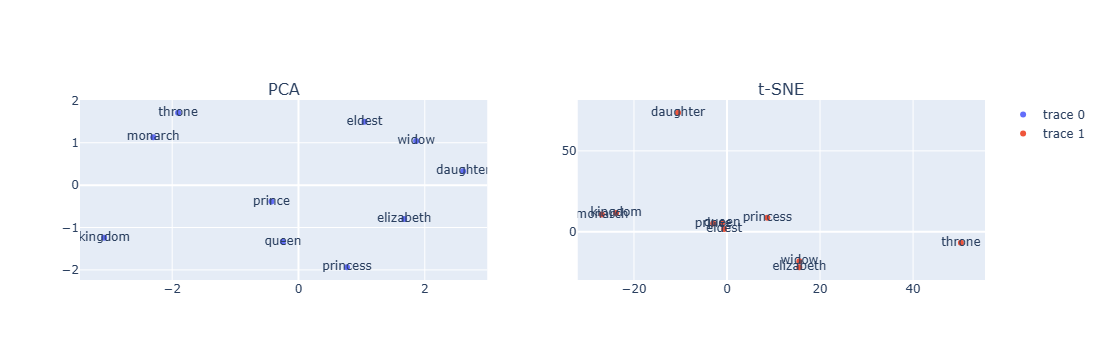

In [7]:
import gensim.downloader as api
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load model once
model = api.load("glove-wiki-gigaword-50")

words = ['queen','throne','prince','daughter','elizabeth','princess','kingdom','monarch','eldest','widow']
X = np.array([model[w] for w in words])

# Reduce dimensions
pca = PCA(2).fit_transform(X)
tsne = TSNE(2, perplexity=5, max_iter=250, random_state=42).fit_transform(X)

# Plot
fig = make_subplots(rows=1, cols=2, subplot_titles=("PCA", "t-SNE"))

fig.add_trace(go.Scatter(x=pca[:,0], y=pca[:,1], mode='markers+text', text=words), row=1, col=1)
fig.add_trace(go.Scatter(x=tsne[:,0], y=tsne[:,1], mode='markers+text', text=words), row=1, col=2)

fig.show()

### EXP 3

In [2]:
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# Data
sentences = [
    "This is a legal document about contracts.",
    "The court will review the legal case.",
    "Medical professionals required specific training.",
    "This is a medical report about the patient."
]

# Train model directly
model = Word2Vec([simple_preprocess(s) for s in sentences],
                 vector_size=50, window=5, min_count=1, epochs=10)

# Output
print(model.wv.most_similar("legal"))

[('case', 0.19024111330509186), ('report', 0.04504139721393585), ('training', -0.010235605761408806), ('the', -0.014461617916822433), ('required', -0.023243648931384087), ('patient', -0.0441020242869854), ('document', -0.04412669315934181), ('professionals', -0.09475670009851456), ('specific', -0.12276171147823334), ('will', -0.1501954346895218)]


### EXP 4

In [1]:
#!pip install transformers gensim nltk

import gensim.downloader as api
from transformers import pipeline
import nltk
nltk.download('punkt')

wv = api.load("glove-wiki-gigaword-100")
gen = pipeline("text-generation", model="gpt2")

p = "who is king"
print("Original:", p)

# Replace "king"
try:
    p2 = p.replace("king", wv.most_similar("king")[0][0])
except:
    p2 = p

print("Enriched:", p2)

# Generate
o1 = gen(p, max_length=100)[0]['generated_text']
o2 = gen(p2, max_length=100)[0]['generated_text']

print("\nOriginal:\n", o1)
print("\nEnriched:\n", o2)

print("\nLength:", len(o1), len(o2))
print("Detail:", o1.count("."), o2.count("."))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chira\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Original: who is king
Enriched: who is prince


[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Original:
 who is king of the Seven Kingdoms, but he is also a traitor to the Seven Kingdoms and a traitor to the people of the Seven Kingdoms," he said.

The British royals have a reputation for corruption, but they rarely do anything that could derail a peace between their two countries.

"They have a very strong sense of loyalty and loyalty to their own people and their own country," Mr. Brown said. "And they are not afraid to work with all of them to make a deal. They are not afraid to have a good relationship with all of the countries that are involved in the diplomatic process. So they are committed to that."

He said the British have always felt they were a part of the world and are committed to doing everything possible to keep that unity alive.

"I think we've always been part of the world," he said. "We've always been a part of the world, and we have always been a part of this world."

The royals have come to believe the world is divided, but Mr. Brown said he does not think

### EXP 6

In [10]:
!pip install transformers

from transformers import pipeline

# Load model
sa = pipeline("sentiment-analysis")

# Function
def analyze(text):
    r = sa(text)[0]
    print(f"\nInput Text: {text}")
    print(f"sentiment: {r['label']} (confidence: {r['score']:.4f})\n")

# Data
reviews = [
    "The product is amazing! I love it so much",
    "I am very disapppinted.The service was terrible.",
    "It was an average experience,nothing special",
    "Absolutely fantastic quality!highly recommended.",
    "Not great,but not the work either."
]

print("\ncustomer sentiment analysis results:")
for r in reviews:
    analyze(r)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Defaulting to user installation because normal site-packages is not writeable


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\chira\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\chira\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


customer sentiment analysis results:

Input Text: The product is amazing! I love it so much
sentiment: POSITIVE (confidence: 0.9999)


Input Text: I am very disapppinted.The service was terrible.
sentiment: NEGATIVE (confidence: 0.9995)


Input Text: It was an average experience,nothing special
sentiment: NEGATIVE (confidence: 0.9996)


Input Text: Absolutely fantastic quality!highly recommended.
sentiment: POSITIVE (confidence: 0.9999)


Input Text: Not great,but not the work either.
sentiment: NEGATIVE (confidence: 0.9942)



### EXP 7

In [4]:
!pip install transformers

from transformers import pipeline

# Load model
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

def sum_text(text):
    text = " ".join(text.split())

    s1 = summarizer(text, max_length=150, min_length=30, do_sample=False)
    s2 = summarizer(text, max_length=150, min_length=30, do_sample=True, temperature=0.9)
    s3 = summarizer(text, max_length=150, min_length=30, do_sample=False, num_beams=5)
    s4 = summarizer(text, max_length=150, min_length=30, do_sample=True, top_k=50, top_p=0.95)

    print("\nOriginal Text:\n", text)

    print("\nSummarized Text:")
    print("\nDefault:", s1[0]['summary_text'])
    print("\nHigh randomness:", s2[0]['summary_text'])
    print("\nConservative:", s3[0]['summary_text'])
    print("\nDiverse sampling:", s4[0]['summary_text'])

long_text = """
Artificial intelligence is a rapidly evolving field of computer science focused on creating intelligent machines capable of mimicking human cognitive functions such as learning, problem-solving, and decision-making. In recent years AI has significantly impacted various industries including healthcare, finance, education and entertainment. AI-powered applications such as chatbots, self-driving cars and recommendation systems have transformed the way we interact with technology. Machine learning and deep learning, subsets of AI, enable systems to learn from data and improve over time without explicit programming. However, AI also poses ethical challenges such as bias in decision-making and concerns over job displacement.
"""

sum_text(long_text)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


config.json: 0.00B [00:00, ?B/s]

C:\Users\chira\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\chira\.cache\huggingface\hub\models--facebook--bart-large-cnn. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


KeyError: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

### EXP 9

In [1]:
import json

data = json.load(open("institutions.json"))

name = input("Enter institution name: ")

if name in data:
    d = data[name]

    print("Founder:", d.get("founder", "N/A"))
    print("Founded:", d.get("founded", "N/A"))
    print("Branches:", ", ".join(d.get("branches", [])) or "N/A")
    print("Employees:", d.get("number_of_employees", "N/A"))
    print("Summary:\n", d.get("summary", "N/A"))

else:
    print("Institution not found.")

FileNotFoundError: [Errno 2] No such file or directory: 'institutions.json'